<a href="https://colab.research.google.com/github/bforoura/ML26/blob/main/Module3_Classification/spam_nospam_sgdclassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Spam Email Detection**

Dataset source: https://www.kaggle.com/datasets/ssssws/spam-email-detection-dataset-clean-and-ml-ready?resource=download

<br>

* In this notebook, we use a spam email detection dataset (spam_email_dataset.csv) to build a complete machine learning pipeline.

* Rather than processing raw text strings with vectorizers, this dataset consists of structured numerical and categorical features extracted from emails.

* **Target Variable**: A binary label column indicating whether an email is   
   * Spam (1)    
   * Non-Spam (0).


* **Numerical Features**: Engineered metrics such as word count, character count, number of links, special character frequencies, etc.


* **Categorical Features**: Attributes such as **sender domain** or **classification** metadata that require **one-hot encoding**.



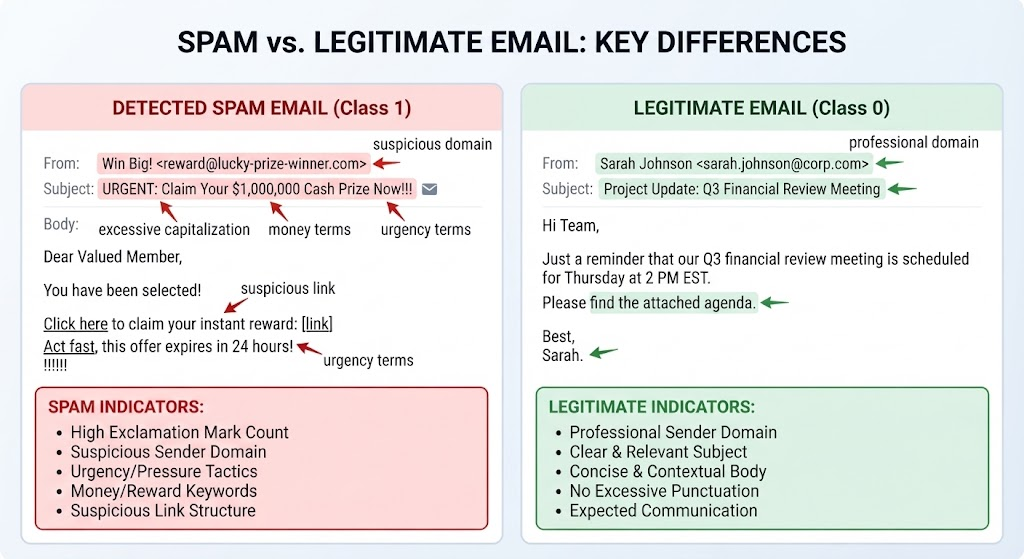

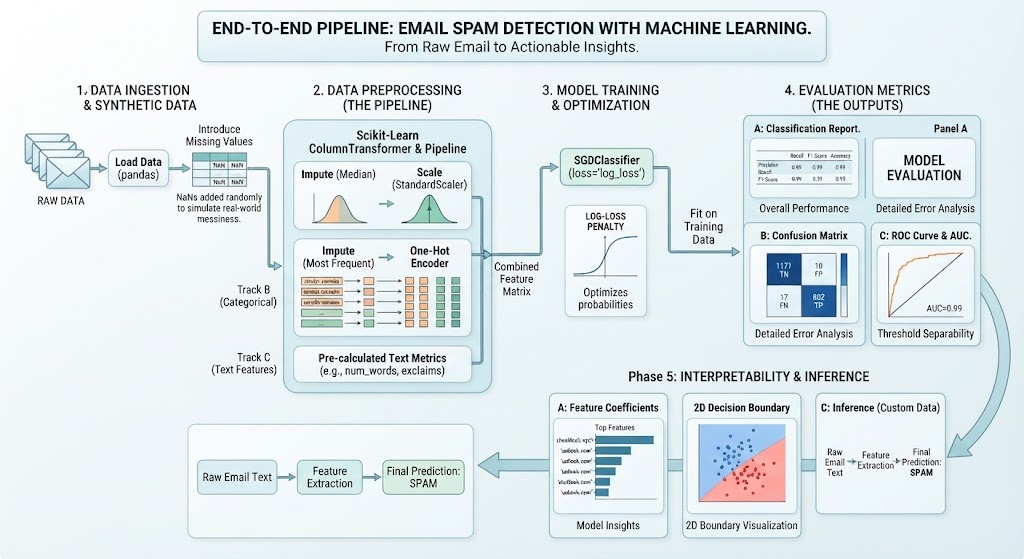

In [ ]:
import pandas as pd

# Load the dataset from the Colab session
df = pd.read_csv('spam_email_dataset.csv')

# Display the dimensions of the dataset
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")

# Display the first 5 rows
display(df.head())

# Print concise summary of columns, non-null counts, and data types
print("\nDataset Information:")
df.info()

Dataset Shape: 10000 rows, 20 columns



,email_id,subject,email_text,num_words,num_characters,num_exclamation_marks,num_links,has_suspicious_link,num_attachments,has_attachment,sender_email,sender_domain,sender_reputation_score,email_hour,email_day_of_week,is_weekend,num_recipients,contains_money_terms,contains_urgency_terms,label
0,0,Weekly Report,budget review - Statement our I claim world st...,19,114,0,2,0,2,1,lctvdzm@outlook.com,outlook.com,0.66,19,3,0,23,0,0,0
1,1,Project Update,team sync - President series today already. In...,18,114,0,7,0,0,0,pxyldmi@company.com,company.com,0.95,4,4,0,16,1,0,0
2,2,🔥WIN BIG NOW!!,win free urgent offer limited limited urgent u...,19,126,0,4,1,1,1,atvanls@unknownmail.cc,unknownmail.cc,0.68,3,0,0,10,1,1,1
3,3,🔥WIN BIG NOW!!,guarantee click now cash offer click now guara...,16,101,0,7,1,1,1,qalxcnf@chealdealz.xyz,chealdealz.xyz,0.69,19,5,1,25,1,1,1
4,4,Meeting Reminder,team sync - Significant property hotel not add...,18,111,0,7,1,2,1,xoiccxl@yahoo.com,yahoo.com,0.67,4,5,1,8,0,0,0



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   email_id                 10000 non-null  int64  
 1   subject                  10000 non-null  object 
 2   email_text               10000 non-null  object 
 3   num_words                10000 non-null  int64  
 4   num_characters           10000 non-null  int64  
 5   num_exclamation_marks    10000 non-null  int64  
 6   num_links                10000 non-null  int64  
 7   has_suspicious_link      10000 non-null  int64  
 8   num_attachments          10000 non-null  int64  
 9   has_attachment           10000 non-null  int64  
 10  sender_email             10000 non-null  object 
 11  sender_domain            10000 non-null  object 
 12  sender_reputation_score  10000 non-null  float64
 13  email_hour               10000 non-null  int64  
 14  e

# **Handling Missing Data and Feature Selection**


* Before building our pipeline, we will select our relevant features and target variable (label).

* To ensure our imputation steps are meaningful, we will inject a small percentage of missing values (NaN) into selected numerical and categorical columns.

* This mirrors real-world messy data and allows our pipeline's **SimpleImputer** steps to demonstrate their functionality.

In [ ]:
import numpy as np

# Select features to keep (dropping raw text and IDs for this structured tabular model)
# We will use numerical features, categorical features, and binary indicators
feature_cols = [
    'num_words', 'num_characters', 'num_exclamation_marks', 'num_links',
    'has_suspicious_link', 'num_attachments', 'sender_domain',
    'sender_reputation_score', 'email_hour', 'is_weekend',
    'contains_money_terms', 'contains_urgency_terms'
]

X = df[feature_cols].copy()
y = df['label']

# Artificially introduce missing values (~5%) into one numerical and one categorical column
# to explicitly demonstrate the Imputer steps in our upcoming pipeline
np.random.seed(42)
num_mask = np.random.rand(len(X)) < 0.05
cat_mask = np.random.rand(len(X)) < 0.05

X.loc[num_mask, 'sender_reputation_score'] = np.nan
X.loc[cat_mask, 'sender_domain'] = np.nan

# Verify missing values have been introduced
print("Missing values introduced for pipeline demonstration:")
print(X[['sender_reputation_score', 'sender_domain']].isnull().sum())

Missing values introduced for pipeline demonstration:
sender_reputation_score    493
sender_domain              496
dtype: int64


# **Train-Test Split and Preprocessing Pipeline Construction**

* We need to **split** our dataset into **training and testing subsets** before applying any transformations to prevent data leakage.

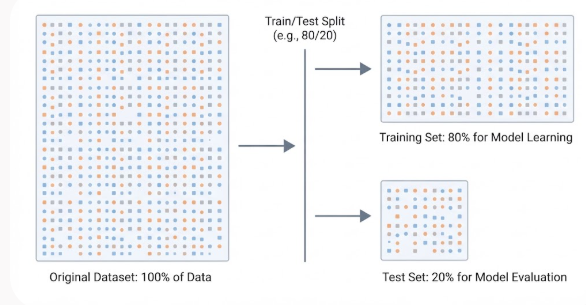
* We then build a scikit-learn **Pipeline** using a **ColumnTransformer** to route numerical and categorical features through separate transformation paths:

  * **Numerical Features**: Impute missing values using the median strategy, then apply StandardScaler to normalize distributions.

  * **Categorical Features**: Impute missing values using the most frequent strategy, then apply **OneHotEncoder** to convert text categories into binary columns.

  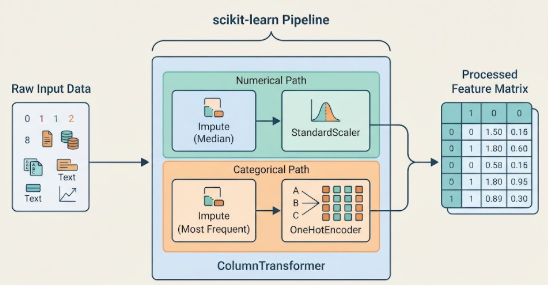


 * **Classifier**: Finally, append an **SGDClassifier** configured with **loss='log_loss'** to enable probability estimation for evaluation metrics.

 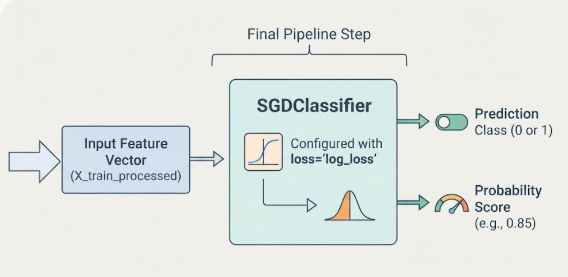

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import SGDClassifier

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Identify numerical and categorical feature columns
numeric_features = [
    'num_words', 'num_characters', 'num_exclamation_marks', 'num_links',
    'has_suspicious_link', 'num_attachments', 'sender_reputation_score',
    'email_hour', 'is_weekend', 'contains_money_terms', 'contains_urgency_terms'
]
categorical_features = ['sender_domain']

# Numerical transformation pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical transformation pipeline
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine transformers using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Assemble full pipeline with preprocessing and classifier
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SGDClassifier(loss='log_loss', max_iter=1000, tol=1e-3, random_state=42))
])

print("Pipeline constructed successfully.")
print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

Pipeline constructed successfully.
Training features shape: (8000, 12)
Testing features shape: (2000, 12)


# **Understanding Log-Loss (Logistic Loss)**


**Log-loss**, also known as **cross-entropy loss**, measures the performance of a classification model whose output is a probability value between $0$ and $1$. Unlike hard-margin classifiers, a logistic loss function penalizes confident yet incorrect predictions heavily.

*  For a single binary data point with true label $y \in \{0, 1\}$ and predicted probability $p = P(y=1)$, the log-loss is defined as:
  $$L_{log}(y, p) = - (y \log(p) + (1 - y) \log(1 - p))$$

* By setting `loss='log_loss'` in our `SGDClassifier`, the model passes its raw linear output (the logit score) through the sigmoid function:
  $$\sigma(z) = \frac{1}{1 + e^{-z}}$$
  This maps any real-valued score into a calibrated probability representing the likelihood of the email being spam.

* If an email is actually spam ($y=1$) and the model assigns it a low probability of $0.01$, the term $-\log(0.01)$ yields a massive penalty. This steep gradient forces stochastic gradient descent to update weights aggressively during training.

* Because log-loss outputs continuous probabilities rather than rigid binary predictions, we can evaluate classification performance across various decision thresholds using Receiver Operating Characteristic (ROC) curves and calculate the Area Under the Curve (AUC).


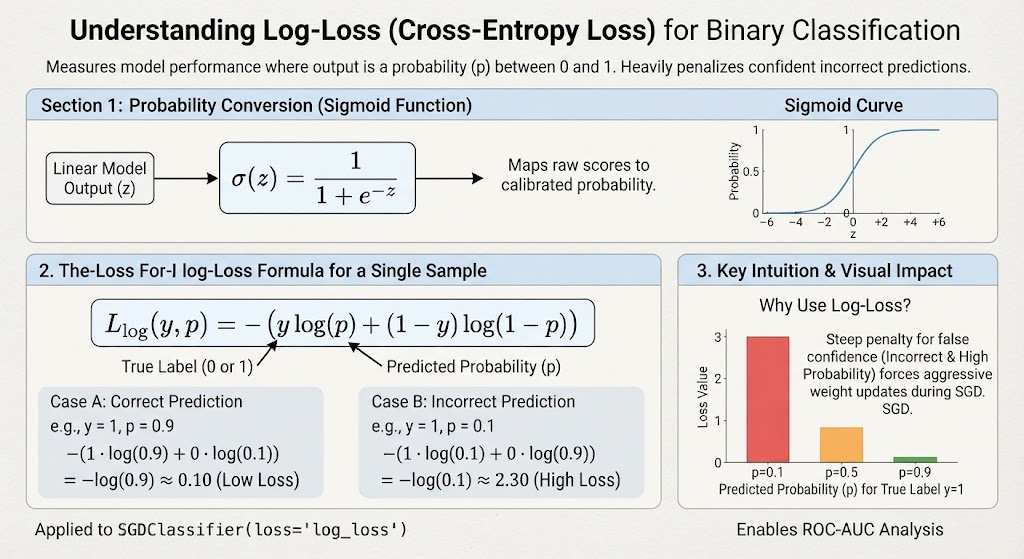

# **Visualizing the Pipeline Structure**

* To help understand how scikit-learn organizes the data flow, we can use scikit-learn's built-in pipeline diagram display (HTML rendering via set_config).

* This creates a visual flowchart showing how features split between the numerical and categorical transformation paths before feeding into the SGDClassifier.

In [ ]:
from sklearn import set_config

# Enable diagram output for scikit-learn estimators and pipelines
set_config(display="diagram")

# Display the constructed pipeline
pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['num_words',
                                                   'num_characters',
                                                   'num_exclamation_marks',
                                                   'num_links',
                                                   'has_suspicious_link',
                                                   'num_attachments',
                                                   'sender_reputation_score',
                                                   'email_hour', 'is_weekend',
                                                   'contains_money_terms',
                                                   'contains_urgency_terms']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sender_domain'])])),
                ('classifier',
                 SGDClassifier(loss='log_loss', random_state=42))])

# **Model Training and Evaluation Metrics**

 * With our pipeline fully defined, we can now train our model on the training data using the **.fit()** method.

 * Once trained, we will generate predictions and evaluate performance using a classification report, a **confusion matrix**, and a **Receiver Operating Characteristic (ROC)** curve with its corresponding **Area Under the Curve (AUC)**



Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1181
           1       0.99      0.98      0.98       819

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000



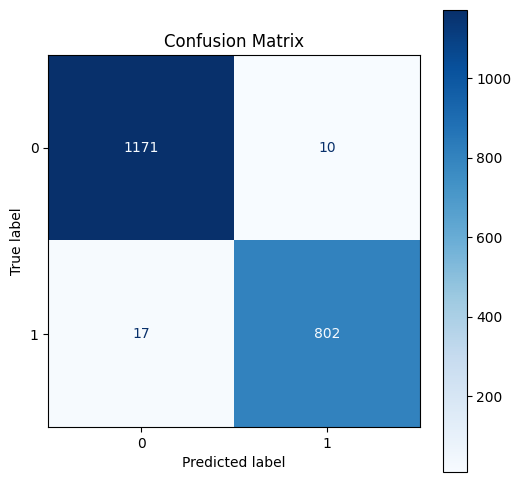

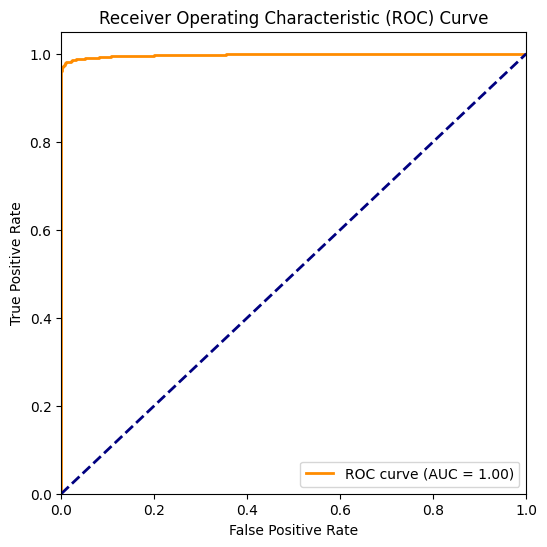

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay

# Fit the entire pipeline on the training data
pipeline.fit(X_train, y_train)

# Generate predictions and probability scores on the test set
y_pred = pipeline.predict(X_test)
y_scores = pipeline.predict_proba(X_test)[:, 1]

# Print classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_estimator(pipeline, X_test, y_test, ax=ax, cmap='Blues', values_format='d')
plt.title('Confusion Matrix')
plt.show()

# Compute ROC Curve and ROC-AUC
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# **Explanation of the Results**

**Classification Report**

  * **Precision**: Out of all emails predicted as class 0 (non-spam), 99% were actually non-spam. Out of all emails predicted as class 1 (spam), 99% were actually spam. This indicates very few false alarms.

  * **Recall**: The model successfully identified 99% of all actual non-spam emails and 98% of all actual spam emails in the test set.

  * **F1-Score**: The harmonic mean of precision and recall sits at 0.99 for non-spam and 0.98 for spam, demonstrating exceptional balance and performance.

  * **Accuracy**: Across all 2,000 test samples, the pipeline achieved an overall accuracy of 99%.

  
---

**ROC Curve and AUC**

 * **Curve Trajectory**: The orange ROC curve hugs the top-left corner of the plot tightly, showing that the model maintains a **high True Positive Rate** while keeping the **False Positive Rate near zero** across a wide range of decision thresholds.

 * **Area Under the Curve**: The **high AUC value** reflects near-optimal separability between the two classes achieved by the combined scaling, imputation, and stochastic gradient descent optimization.


# **Inspecting Feature Coefficients**

* To understand what the **SGDClassifier** learned during training, we can extract the feature names after preprocessing—including the expanded one-hot encoded categorical columns—and examine the corresponding model coefficients.

* **Positive coefficients** push predictions toward **spam**, while **negative coefficients** indicate **legitimate emails (hams)**.

In [ ]:
import pandas as pd

# Extract feature names from the preprocessor step
cat_encoder = pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
encoded_cat_features = cat_encoder.get_feature_names_out(categorical_features).tolist()

# Combine numerical and encoded categorical feature names
all_feature_names = numeric_features + encoded_cat_features

# Retrieve coefficients from the SGDClassifier step
coefficients = pipeline.named_steps['classifier'].coef_[0]

# Create a DataFrame to view feature importance
feature_importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False)

# Display top features pushing toward spam and non-spam
print("Top features pushing toward Spam:")
print(feature_importance_df.head(10))

print("\nTop features pushing toward Legitimate (Non-Spam):")
print(feature_importance_df.tail(10))

Top features pushing toward Spam:
                         Feature  Coefficient
11  sender_domain_chealdealz.xyz     5.037378
17    sender_domain_winbignow.ru     4.866261
13   sender_domain_freemoney.biz     4.793743
16  sender_domain_unknownmail.cc     4.706989
0                      num_words     1.680847
10        contains_urgency_terms     1.170618
9           contains_money_terms     1.069938
8                     is_weekend     0.058508
3                      num_links     0.048798
7                     email_hour     0.008559

Top features pushing toward Legitimate (Non-Spam):
                      Feature  Coefficient
7                  email_hour     0.008559
2       num_exclamation_marks     0.000000
4         has_suspicious_link    -0.222122
1              num_characters    -0.432309
5             num_attachments    -0.763213
6     sender_reputation_score    -1.404174
18    sender_domain_yahoo.com    -2.497476
14    sender_domain_gmail.com    -5.505243
12  sender_domain_com

# **Understanding Model Coefficients**

* The above output displays the learned weights assigned by the `SGDClassifier` to each feature after training.

* In a linear classification model, the magnitude and sign of each coefficient determine how strongly a feature influences the final prediction.



* **Positive Coefficients (Spam Indicators):** Features with positive values push the decision boundary toward classifying an email as spam (1). For instance, specific suspicious sender domains like `sender_domain_chealdealz.xyz` (+5.04) and high-pressure text characteristics like `contains_urgency_terms` (+1.17) strongly increase the model's spam score.
* **Negative Coefficients (Legitimate Indicators):** Features with negative values push the prediction toward legitimate mail (0). Trusted providers like `sender_domain_outlook.com` (-5.62) and higher `sender_reputation_score` values (-1.40) heavily decrease the probability of an email being flagged as spam.

# **Visualizing the 2D Decision Boundary**


* To visualize how the linear classifier separates spam from non-spam graphically:
  * isolate two prominent numerical features (such as num_words and num_exclamation_marks)
   * train a dedicated 2D pipeline
   * plot the resulting decision boundary using a mesh grid and a scatter plot of the data points.

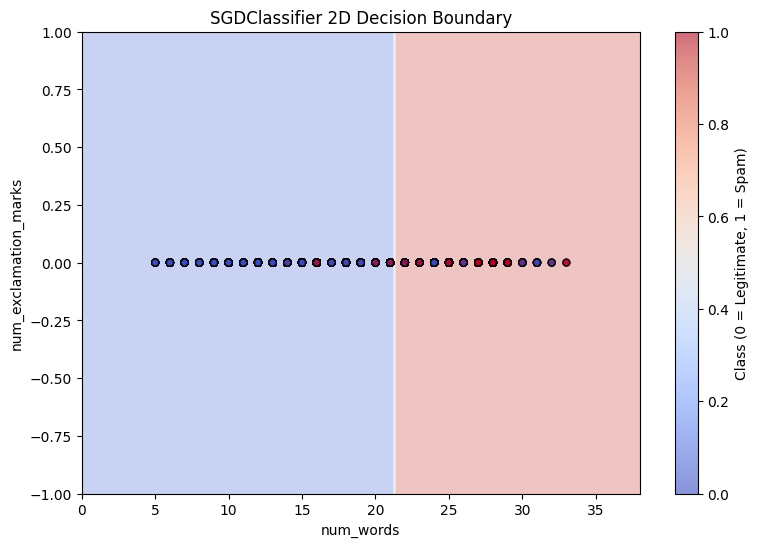

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import SGDClassifier

# Select two prominent numerical features for 2D visualization
feat_1 = 'num_words'
feat_2 = 'num_exclamation_marks'

X_2d = X_train[[feat_1, feat_2]].copy()

# Build a pipeline for these two features
clf_2d = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('classifier', SGDClassifier(loss='log_loss', max_iter=1000, random_state=42))
])

# Train the 2D model
clf_2d.fit(X_2d, y_train)

# Create a mesh grid to plot the decision boundary
x_min, x_max = X_2d[feat_1].min() - 5, X_2d[feat_1].max() + 5
y_min, y_max = X_2d[feat_2].min() - 1, X_2d[feat_2].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

# Predict over the mesh grid
grid_points = np.c_[xx.ravel(), yy.ravel()]
grid_df = pd.DataFrame(grid_points, columns=[feat_1, feat_2])
Z = clf_2d.predict(grid_df)
Z = Z.reshape(xx.shape)

# Plotting the decision boundary and data points
plt.figure(figsize=(9, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)

# Scatter plot of training samples
scatter = plt.scatter(X_2d[feat_1], X_2d[feat_2], c=y_train, cmap=plt.cm.coolwarm, edgecolors='k', s=25, alpha=0.6)
plt.xlabel(feat_1)
plt.ylabel(feat_2)
plt.title('SGDClassifier 2D Decision Boundary')
plt.colorbar(scatter, label='Class (0 = Legitimate, 1 = Spam)')
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.show()

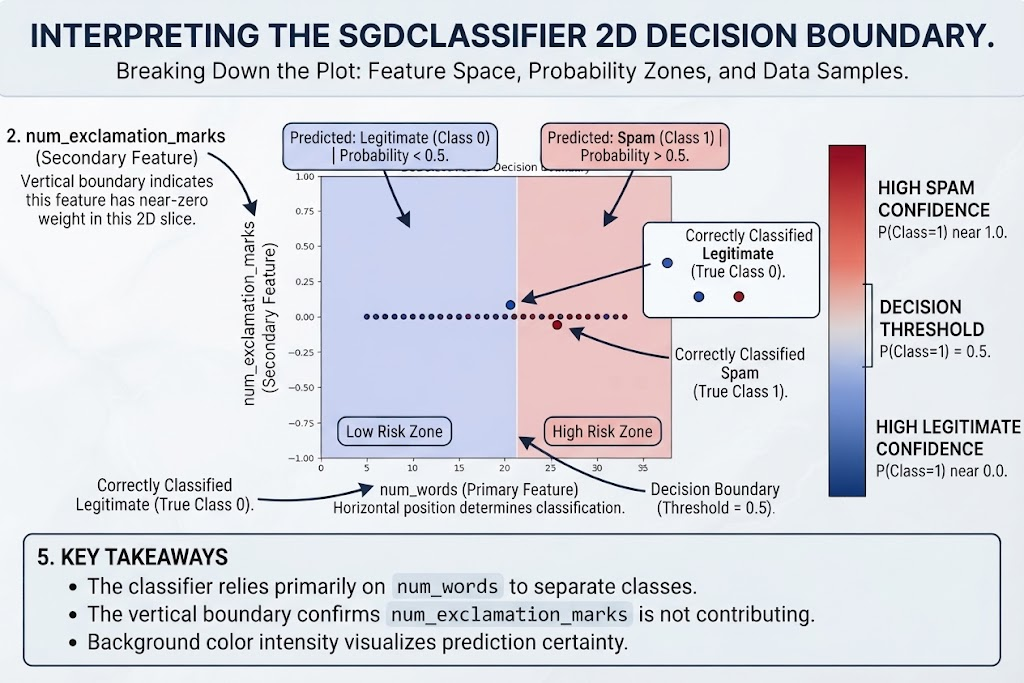

# **From Raw Text to Feature Extraction and Classification**


* In real-world applications, **raw email** text must first be parsed into numerical and categorical features before being passed to a tabular machine learning model.

* In this cell, we recreate a raw email text sample, use regular expressions to extract its features, assemble a DataFrame, and pass it directly through our trained scikit-learn pipeline to generate a final classification and probability score.

In [ ]:
import re
import pandas as pd
import numpy as np

# Recreate the raw email text for demonstration purposes
raw_email_text = """
Subject: CLAIM YOUR MILLIONS NOW!!! Exclusive Mega Win Opportunity!
From: manager@chealdealz.xyz
To: user@company.com

Dear Winner,
You have been randomly selected to claim your instant cash prize of $1,000,000!
This is a limited-time offer. Click the secure link below immediately to claim your funds:
http://chealdealz.xyz/claim-prize?user=9982

Act fast before this expires!
"""

# Parse raw text into features used by our pipeline
parsed_features = {
    'num_words': len(raw_email_text.split()),
    'num_characters': len(raw_email_text),
    'num_exclamation_marks': raw_email_text.count('!'),
    'num_links': len(re.findall(r'http[s]?://\S+', raw_email_text)),
    'has_suspicious_link': 1 if 'xyz' in raw_email_text else 0,
    'contains_money_terms': 1 if re.search(r'\$|\bmillion\b|\bcash\b', raw_email_text, re.IGNORECASE) else 0,
    'contains_urgency_terms': 1 if re.search(r'\bnow\b|\blimited-time\b|\bact fast\b', raw_email_text, re.IGNORECASE) else 0
}

print("Raw Email Content:\n", raw_email_text)
print("\nExtracted Features for Pipeline:")
for k, v in parsed_features.items():
    print(f"  - {k}: {v}")

# Create a DataFrame containing our extracted features combined with other required fields
extracted_email_df = pd.DataFrame([{
    'num_words': parsed_features['num_words'],
    'num_characters': parsed_features['num_characters'],
    'num_exclamation_marks': parsed_features['num_exclamation_marks'],
    'num_links': parsed_features['num_links'],
    'has_suspicious_link': parsed_features['has_suspicious_link'],
    'num_attachments': 0,
    'sender_domain': 'chealdealz.xyz',
    'sender_reputation_score': 0.1,
    'email_hour': 22,
    'is_weekend': 0,
    'contains_money_terms': parsed_features['contains_money_terms'],
    'contains_urgency_terms': parsed_features['contains_urgency_terms']
}])

# Run the trained pipeline on the newly parsed email data
pred_class = pipeline.predict(extracted_email_df)[0]
pred_proba = pipeline.predict_proba(extracted_email_df)[0][1]

print("\n--- Running Pipeline on Parsed Raw Email ---")
print(f"Classification Result: {'Spam (1)' if pred_class == 1 else 'Legitimate (0)'}")
print(f"Spam Probability Score: {pred_proba:.4f}")

Raw Email Content:
 
Subject: CLAIM YOUR MILLIONS NOW!!! Exclusive Mega Win Opportunity!
From: manager@chealdealz.xyz
To: user@company.com

Dear Winner,
You have been randomly selected to claim your instant cash prize of $1,000,000! 
This is a limited-time offer. Click the secure link below immediately to claim your funds:
http://chealdealz.xyz/claim-prize?user=9982

Act fast before this expires!


Extracted Features for Pipeline:
  - num_words: 49
  - num_characters: 380
  - num_exclamation_marks: 6
  - num_links: 1
  - has_suspicious_link: 1
  - contains_money_terms: 1
  - contains_urgency_terms: 1

--- Running Pipeline on Parsed Raw Email ---
Classification Result: Spam (1)
Spam Probability Score: 1.0000
